# Homework 3 Solutions

Financial Data Science II, Fall 2020

These solutions represent the contributions of multiple students, plus some of my edits.

### Question 1

In [1]:
import pandas as pd
from KDEpy import FFTKDE
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
import yfinance as yf
import statsmodels.api as sm

In [2]:
#1.1
optionsdata = pd.read_csv("optionssample09302017.txt", sep=",")
askprice=optionsdata["ask"]
askprice=np.array(askprice)

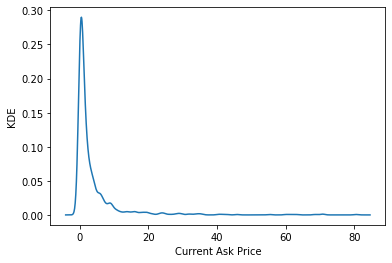

In [3]:
x,y = FFTKDE(kernel='gaussian', bw='silverman').fit(askprice).evaluate()
plt.plot(x, y)
plt.xlabel("Current Ask Price")
plt.ylabel("KDE")
plt.show()

The distribution of current ask price has a long upper tail, skewed to the right. Even when the ask price is transformed using, for example, a square root transform, the skew remains evident.

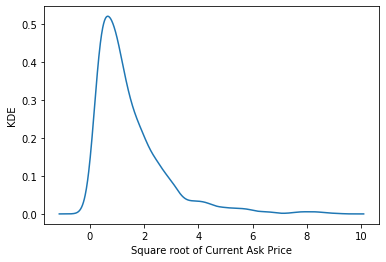

In [4]:
x,y = FFTKDE(kernel='gaussian', bw='silverman').fit(np.sqrt(askprice)).evaluate()
plt.plot(x, y)
plt.xlabel("Square root of Current Ask Price")
plt.ylabel("KDE")
plt.show()

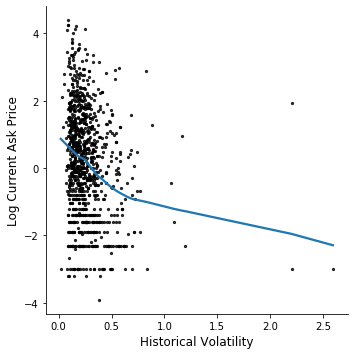

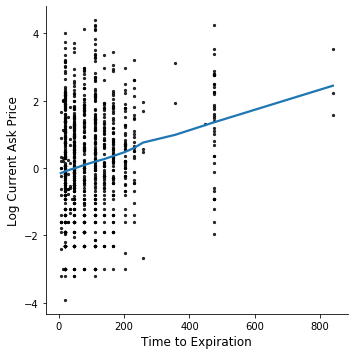

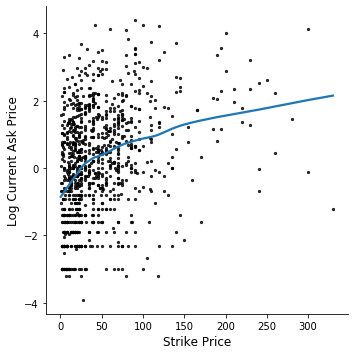

In [5]:
optionsdata=optionsdata[optionsdata["ask"]>0]
optionsdata["log_askprice"]=np.log(optionsdata["ask"])

sns.lmplot(y="log_askprice", x="histvol", data=optionsdata, lowess=True, scatter_kws={"s": 5, "color": "black"})
plt.ylabel("Log Current Ask Price",size=12)
plt.xlabel("Historical Volatility",size=12)

sns.lmplot(y="log_askprice", x="timetoexpiry", data=optionsdata, lowess=True, scatter_kws={"s": 5, "color": "black"})
plt.ylabel("Log Current Ask Price",size=12)
plt.xlabel("Time to Expiration",size=12)

sns.lmplot(y="log_askprice", x="strike", data=optionsdata, lowess=True, scatter_kws={"s": 5, "color": "black"})
plt.ylabel("Log Current Ask Price",size=12)
plt.xlabel("Strike Price",size=12)

plt.show()

We need to keep in mind when considering these plots that we are looking at marginal relationships between each variable and the current ask price. These projections can smear and distort what one might consider to be the appropriate relationships between these variables.

In particular, we are looking at a sample taken a fixed point in time. These plots are not telling us what would happen to ask price if, for example, strike price is increased while holding all other properties constant.

For example, the options within the sample with small historical volatility will, on average, have smaller strike prices, smaller current prices and smaller ask prices. This will lead to a reverse relationship in the plot compared to what one may expect from options theory.

### Question 2

**Step 1:** Start by installing the Python package `get-all-tickers`. You can find more information on this package at https://github.com/shilewenuw/get_all_tickers.

Once this is installed, the following code will give you a list of all of the NYSE ticker symbols.

In [6]:
from get_all_tickers import get_tickers as gt

NYSEtickers = gt.get_tickers(NYSE=True,NASDAQ=False,AMEX=False)

**Step 2:** Randomly choose 200 of the ticker symbols from the list. **This is important; working with the entire list will be too time consuming.**

In [7]:
random.seed(0)
selectedTickers = np.random.choice(NYSEtickers, size=300, replace=False)

**Step 3:** For each of your chosen symbols, obtain the market data from January and February of 2020. Below is an example of one such call. 

In [8]:
rawData = yf.download(selectedTickers.tolist(), start="2020-01-01", end="2020-03-01")['Adj Close']

[****                   8%                       ]  23 of 300 downloaded

Exception in thread Thread-4:
Traceback (most recent call last):
  File "/Users/chadschafer/anaconda3/lib/python3.7/threading.py", line 917, in _bootstrap_inner
    self.run()
  File "/Users/chadschafer/anaconda3/lib/python3.7/threading.py", line 865, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/multitasking/__init__.py", line 102, in _run_via_pool
    return callee(*args, **kwargs)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 537, in _download_one_threaded
    period, interval, prepost, proxy, rounding)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 550, in _download_one
    proxy=proxy, rounding=rounding)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 354, in history
    raise ValueError(self.ticker, err_msg)
ValueError: ('ASAN', "Data doesn't exist for startDate = 157785480

[******                13%                       ]  39 of 300 downloaded

Exception in thread Thread-32:
Traceback (most recent call last):
  File "/Users/chadschafer/anaconda3/lib/python3.7/threading.py", line 917, in _bootstrap_inner
    self.run()
  File "/Users/chadschafer/anaconda3/lib/python3.7/threading.py", line 865, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/multitasking/__init__.py", line 102, in _run_via_pool
    return callee(*args, **kwargs)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 537, in _download_one_threaded
    period, interval, prepost, proxy, rounding)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 550, in _download_one
    proxy=proxy, rounding=rounding)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 354, in history
    raise ValueError(self.ticker, err_msg)
ValueError: ('CIXX', "Data doesn't exist for startDate = 15778548

[*************         28%                       ]  84 of 300 downloaded

...

[**********************77%************           ]  232 of 300 downloaded

Exception in thread Thread-205:
Traceback (most recent call last):
  File "/Users/chadschafer/anaconda3/lib/python3.7/threading.py", line 917, in _bootstrap_inner
    self.run()
  File "/Users/chadschafer/anaconda3/lib/python3.7/threading.py", line 865, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/multitasking/__init__.py", line 102, in _run_via_pool
    return callee(*args, **kwargs)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 537, in _download_one_threaded
    period, interval, prepost, proxy, rounding)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 550, in _download_one
    proxy=proxy, rounding=rounding)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 354, in history
    raise ValueError(self.ticker, err_msg)
ValueError: ('AIRC$', 'No data found, symbol may be delisted')



[**********************86%****************       ]  258 of 300 downloaded

Exception in thread Thread-274:
Traceback (most recent call last):
  File "/Users/chadschafer/anaconda3/lib/python3.7/threading.py", line 917, in _bootstrap_inner
    self.run()
  File "/Users/chadschafer/anaconda3/lib/python3.7/threading.py", line 865, in run
    self._target(*self._args, **self._kwargs)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/multitasking/__init__.py", line 102, in _run_via_pool
    return callee(*args, **kwargs)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 537, in _download_one_threaded
    period, interval, prepost, proxy, rounding)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 550, in _download_one
    proxy=proxy, rounding=rounding)
  File "/Users/chadschafer/anaconda3/lib/python3.7/site-packages/yfinance/__init__.py", line 354, in history
    raise ValueError(self.ticker, err_msg)
ValueError: ('FOUR', "Data doesn't exist for startDate = 1577854

[*********************100%***********************]  283 of 300 downloaded


Remove any ticker that has not data or has missing data.

In [9]:
filterData = {k:v for k,v in rawData.items() if ((not v.empty) and (not v.isnull().sum()) and (len(v)==40))}
len(filterData)

280

Randomly choose 200 out of those with complete coverage.

In [10]:
filterData = {t:filterData[t] for t in np.random.choice(list(filterData.keys()), size=200, replace=False)}
len(filterData)

200

Scale each series to have mean zero and variance one.

In [11]:
from sklearn import preprocessing

scaledDf = pd.DataFrame(filterData).copy()
for c in scaledDf.columns:
    scaledDf[c] = preprocessing.scale(scaledDf[c])

Transpose the data frame so that each symbol is a row.

In [12]:
dataDf = scaledDf.transpose()

In [13]:
import rpy2
%load_ext rpy2.ipython

In [14]:
%%R
library(fANCOVA)

/Users/chadschafer/anaconda3/lib/python3.7/site-packages/rpy2/rinterface/__init__.py:146: RRuntimeWarning: fANCOVA 0.5-1 loaded

  warnings.warn(x, RRuntimeWarning)


In [15]:
janDays = range(21)
febDays = range(21,40)

janData = dataDf.iloc[:,janDays].copy()
febData = dataDf.iloc[:,febDays].copy()

In [16]:
%%R -i janData -o janOptVals -o rowNames
janOptVals <- double(nrow(janData))
rowNames <- character(nrow(janData))
for (i in 1:nrow(janData)) {
    fit <- loess.as(1:length(janData[i,]), as.numeric(janData[i,]), criterion = "aicc")
    janOptVals[i] <- fit$pars$span
    rowNames[i] <- row.names(janData[i,])
}

/Users/chadschafer/anaconda3/lib/python3.7/site-packages/rpy2/robjects/pandas2ri.py:191: FutureWarning: from_items is deprecated. Please use DataFrame.from_dict(dict(items), ...) instead. DataFrame.from_dict(OrderedDict(items)) may be used to preserve the key order.
  res = PandasDataFrame.from_items(items)


In [17]:
%%R -i febData -o febOptVals -o rowNames
febOptVals <- double(nrow(febData))
rowNames <- character(nrow(febData))
for (i in 1:nrow(febData)) {
    fit <- loess.as(1:length(febData[i,]), as.numeric(febData[i,]), criterion = "aicc")
    febOptVals[i] <- fit$pars$span
    rowNames[i] <- row.names(febData[i,])
}

Calculate the volatility within each month.

In [18]:
dataDf['janVol']=dataDf.iloc[:, janDays].std(axis=1)
dataDf['febVol']=dataDf.iloc[:, febDays].std(axis=1)

In [19]:
dataDf['janVolSmo']= dataDf['janVol']
dataDf['febVolSmo']= dataDf['janVol']

for t in range(200):
    dataDf.iloc[t, 42]=np.std(sm.nonparametric.lowess(\
        dataDf.iloc[t, janDays], janDays, frac=janOptVals[t])[:,1])
    dataDf.iloc[t, 43]=np.std(sm.nonparametric.lowess(\
        dataDf.iloc[t, febDays], febDays, frac=febOptVals[t])[:,1])

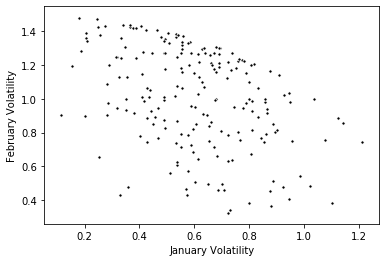

In [20]:
import seaborn as sn

g = sn.scatterplot(data=dataDf, x='janVol', y='febVol', s=10, color='black')
plt.xlabel("January Volatility")
plt.ylabel("February Volatility")
plt.show()

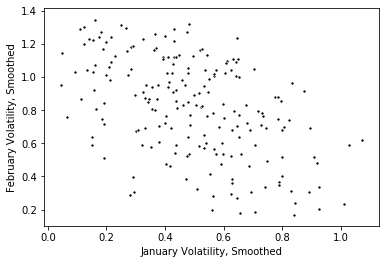

In [21]:
import seaborn as sn

g = sn.scatterplot(data=dataDf, x='janVolSmo', y='febVolSmo', s=10, color='black')
plt.xlabel("January Volatility, Smoothed")
plt.ylabel("February Volatility, Smoothed")
plt.show()